In [1]:
import cv2
import json
import numpy as np
import os
import matplotlib.cm as cm


def rescale_image(image, max_height, max_width):
    """ Rescale image so that longest dimension equals max size.
    
    Args:
        image: 3d numpy array
        max_size: number longest output size of image
    """
    
    im_size = np.array(image.shape)
    scale = max_height / im_size[0]
    new_im_shape = (im_size * scale).astype(int)
    if new_im_shape[1] > max_width:
        scale = max_width / im_size[1] 
    new_im_shape = (im_size * scale).astype(int)
    new_image = cv2.resize(image, (new_im_shape[1], new_im_shape[0]))
    
    return new_image, scale


class PronghornValidationGUI():
    
    #constructor
    def __init__(self, scores_files, label_root, image_root, herd_unit, model_name, score_threshold, window_width):
        """ 
        Args:
            scores_files: list of scores files. These could be sorted based on score values
            label_root: path to the folder containing the model output folder
            image_root: path to the folder containing the images
            herd_unit: name of the herd unit i.e. "PR529"
            model_name: name of the model i.e. "03-24-2025-11-46-27"
            score_threshold: minimum score to display
            window_width: Width dimension in pixels of output display
        """

        self.scores_files = scores_files
        self.label_root = label_root
        self.image_root = image_root
        self.herd_unit = herd_unit
        self.model = model_name
        self.score_threshold = score_threshold
        self.max_height = window_width
        self.max_width = window_width
        
        self.crop_buffer = 100
        self.draw_boxes = True
        
        self.show_points = True
        self.file_ind = 0
        
        # self.colors = self.get_colors()
        self.load_new_frame()
        
    def load_new_frame(self):
        """ Load image and corresponding annotations (if they exist)."""
        scores_file = self.scores_files[self.file_ind]
        image_name = os.path.splitext(os.path.basename(scores_file))[0].split("_scores")[0]
        self.image_name = image_name
        boxes_file = os.path.join(self.label_root, self.model, f"{image_name}_boxes.npy")
        image_file = os.path.join(self.image_root, f"{image_name}.JPG")
        labels_file = os.path.join(self.label_root, self.model, f"{image_name}_labels.npy")
        self.gtlabels_file = os.path.join(self.label_root, self.model, f"{self.image_name}_gtlabels.npy")

        self.boxes = np.load(boxes_file)
        self.labels = np.load(labels_file)
        self.scores = np.load(scores_file)
        if os.path.exists(self.gtlabels_file):
            self.gt_labels = np.load(self.gtlabels_file)
        else:
            # If no gt file exists, create a blank one
            # Set all labels to -1
            self.gt_labels = np.ones_like(self.scores) * -1

        self.valid_inds = self.get_valid_pronghorn_inds()
        if len(self.valid_inds) == 0:
            if self.file_ind < len(self.scores_files) - 1:
                self.change_frame(1)
            else:
                print("No more frames to process.")
            return True
        
        self.raw_frame = cv2.imread(image_file)
        self.ph_ind = 0
        self.display_crop()

    def get_valid_pronghorn_inds(self):
        """ Get the indices of the pronghorns that are valid."""
        pronghorn_class = 2
        
        valid_inds = []
        for ind, (score, label) in enumerate(zip(self.scores, self.labels)):
            if (score < self.score_threshold) or (label != pronghorn_class):
                continue
            valid_inds.append(ind)
            
        return valid_inds
    
    def get_bbox_overlap(self, box1, box2):
        """ Get the overlap between two boxes.
        
        Args:
            box1: [xmin, ymin, xmax, ymax]
            box2: [xmin, ymin, xmax, ymax]
        
        Returns:
            overlap: True if boxes overlap
        """
        box2_left = box1[0] > box2[2]
        box2_right = box1[2] < box2[0]
        box2_top = box1[1] > box2[3]
        box2_bottom = box1[3] < box2[1]

        return not (box2_left or box2_right or box2_top or box2_bottom)
    
    def get_overlapping_boxes(self, box, boxes):
        """ Get the overlapping boxes for a given box.
        
        Args:
            box: [xmin, ymin, xmax, ymax]
            boxes: list of boxes to check against
        
        Returns:
            overlapping_boxes: list of overlapping boxes
        """
        overlapping_boxes = []
        for ind, box2 in enumerate(boxes):
            if ind != self.valid_inds:
                continue
            if self.get_bbox_overlap(box, box2):
                overlapping_boxes.append(box2)
        return overlapping_boxes
    
    def get_crop(self, image, box, overlapping_boxes):
        # Crop image to the area of interest
        ymin = np.max([int(box[1]) - self.crop_buffer, 0]) # casting from uint32 to int
        ymax = np.min([box[3] + self.crop_buffer, image.shape[0]])
        xmin = np.max([int(box[0]) - self.crop_buffer, 0])
        xmax = np.min([box[2] + self.crop_buffer, image.shape[1]])

        crop = image[ymin:ymax, xmin:xmax].copy()

        if self.draw_boxes:
            colors = {-1: (255, 255, 255), # unlabeled
                     0: (0, 0, 0), # not pronghorn
                     1: (0, 0, 255), # unknown ungulate
                     2: (255, 0, 0), # pronghorn
                     3: (255, 0, 255), # elk
                     4: (0, 255, 255), # unsure
                     5: (0, 255, 100) # cow
                     }
            color = colors[self.gt_labels[self.valid_inds[self.ph_ind]]]
            cv2.rectangle(crop, 
                          (box[0] - xmin, box[1] - ymin), 
                          (box[2] - xmin, box[3] - ymin), 
                          color, 1)
            for box2 in overlapping_boxes:
                cv2.rectangle(crop, 
                              (box2[0] - xmin, box2[1] - ymin), 
                              (box2[2] - xmin, box2[3] - ymin), 
                              (0, 255, 0), 1)
        return crop


    def display_crop(self):
        """ Crop image to the area of interest, and rescale."""
        box = self.boxes[self.valid_inds[self.ph_ind]]
        score = self.scores[self.valid_inds[self.ph_ind]]

        overlapping_boxes = self.get_overlapping_boxes(box, self.boxes)
        crop = self.get_crop(self.raw_frame, box, overlapping_boxes)
        # Rescale image
        self.crop, self.frame_rescale = rescale_image(crop, 
                                                      self.max_height, 
                                                      self.max_width)

        if os.path.exists(self.gtlabels_file):
            color = (0, 0, 0)
        else:
            color = (255, 255, 255)
        cv2.putText(self.crop,f"{self.file_ind}-{self.ph_ind}",
                                (10, 20),
                                cv2.FONT_HERSHEY_SIMPLEX,
                                0.5,
                                color, 1)
        cv2.imshow('frame', self.crop)
        
        
    def save_frame_info(self):
        """ Save current keypoint annotations as json file."""
        np.save(self.gtlabels_file, self.gt_labels)
        
    def change_frame(self, amount):
        """Change test frame forward or backward by amount.
        0 is minimum frame ind and number of frames is max (no periodic boundaries)
        
        Args:
            amount: number of frames to move positive or negative"""
        
        self.save_frame_info()
        self.file_ind += amount 
        self.file_ind = np.max([0, self.file_ind])
        self.file_ind = np.min([len(self.scores_files)-1, self.file_ind])
        self.load_new_frame()

    def change_crop(self, amount):
        """Change pronghorn ind forward or backward by amount.
        0 is minimum ind and number of pronghorn is max (no periodic boundaries)
        
        Args:
            amount: number of frames to move positive or negative"""
        
        self.ph_ind += amount
        if self.ph_ind < 0:
            self.change_frame(-1)
            return True
        if self.ph_ind >= len(self.valid_inds):
            self.change_frame(1)
            return True
        self.display_crop()
        
        
    def react_to_keypress(self, key):
        """ Process key press
        Args:
            key: return from cv2 cv2.waitkey
        """
        
        if key == ord('l'):
            self.change_crop(1)
        elif key == ord('j'):
            self.change_crop(-1)
        elif key == ord('0'):
            self.gt_labels[self.valid_inds[self.ph_ind]] = 0
            self.change_crop(1)
        elif key == ord('1'):
            self.gt_labels[self.valid_inds[self.ph_ind]] = 1
            self.change_crop(1)
        elif key == ord('2'):   
            self.gt_labels[self.valid_inds[self.ph_ind]] = 2
            self.change_crop(1)
        elif key == ord('3'):
            self.gt_labels[self.valid_inds[self.ph_ind]] = 3
            self.change_crop(1)
        elif key == ord('4'):
            self.gt_labels[self.valid_inds[self.ph_ind]] = 4
            self.change_crop(1)
        elif key == ord('5'):
            self.gt_labels[self.valid_inds[self.ph_ind]] = 5
            self.change_crop(1)
        elif key == ord('n'):
            self.change_frame(-1)
        elif key == ord('m'):
            self.change_frame(1)
        elif key == ord('p'):
            self.toggle_show_points()
            
            
    def toggle_show_points(self):
        self.draw_boxes = not self.draw_boxes
        self.display_crop()

In [10]:
import glob
import math
import os

import cv2
import matplotlib.pyplot as plt
import numpy as np

In [13]:
label_root = "/home/koger/pronghorn-processing"
label_root = "/mnt/c/Users/benko/Dropbox/UWyo/pronghorn-census"
herd_unit = "PR529"
image_root = f"/mnt/h/Pronghorn Vertical Imagery/2024/{herd_unit}"
model = "06-18-2025-18-43-48-with-gts"

In [14]:
scores_files = sorted(glob.glob(os.path.join(label_root, model, f"{herd_unit.lower()}*scores*.npy")))
labels_files = sorted(glob.glob(os.path.join(label_root, model, f"{herd_unit.lower()}*_labels*.npy")))
gt_labels_files = sorted(glob.glob(os.path.join(label_root, model, f"{herd_unit.lower()}*gtlabels*.npy")))
print(len(scores_files), len(labels_files), len(gt_labels_files))

948 948 948


In [5]:
# Change this value to make the GUI window bigger or smaller
window_width = 500

gui = PronghornValidationGUI(scores_files, label_root, image_root, herd_unit, model, score_threshold=.2,
                             window_width=window_width)

cv2.namedWindow('frame')

while True:
    # gui.draw_keypoints()
    key = cv2.waitKey(500) & 255
    gui.react_to_keypress(key)
    if key == ord('q'):
        gui.save_frame_info()
        print('quitting')
        break
cv2.destroyAllWindows()
cv2.waitKey(1)
cv2.destroyAllWindows()
cv2.waitKey(1)
cv2.destroyAllWindows()
cv2.waitKey(1)

error: OpenCV(4.11.0) /io/opencv/modules/highgui/src/window.cpp:1301: error: (-2:Unspecified error) The function is not implemented. Rebuild the library with Windows, GTK+ 2.x or Cocoa support. If you are on Ubuntu or Debian, install libgtk2.0-dev and pkg-config, then re-run cmake or configure script in function 'cvShowImage'


In [15]:
gt_labels_files[0]

'/mnt/c/Users/benko/Dropbox/UWyo/pronghorn-census/06-18-2025-18-43-48-with-gts/pr529_by2023_survey1_flight1_00001_20240627_152152_gtlabels.npy'

In [16]:
gt_labels = []
scores = []
for gt_label_file in gt_labels_files:
    name = gt_label_file.split("_gtlabels")[0]
    scores_file = name + "_scores.npy"
    gt_labels.append(np.load(gt_label_file))
    scores.append(np.load(scores_file))

['/home/koger/pronghorn-processing/06-18-2025-18-43-48/pr529_by2023_survey1_flight1_00001_20240627_152152_gtlabels.npy']

In [17]:
pronghorn_scores = []
false_positive_scores = []
uncertain_scores = []
for im_labels, im_scores in zip(gt_labels, scores):
    uncertain_scores.append(im_scores[(im_labels == 1) | (im_labels == 4)])
uncertain_scores = np.concatenate(uncertain_scores)

for im_labels, im_scores in zip(gt_labels, scores):
    false_positive_scores.append(im_scores[im_labels == 0])
false_positive_scores = np.concatenate(false_positive_scores)
for im_labels, im_scores in zip(gt_labels, scores):
    pronghorn_scores.append(im_scores[im_labels == 2])
pronghorn_scores = np.concatenate(pronghorn_scores)
print(f"{len(pronghorn_scores)} pronghorn found")
pronghorn_scores.sort()


131 pronghorn found


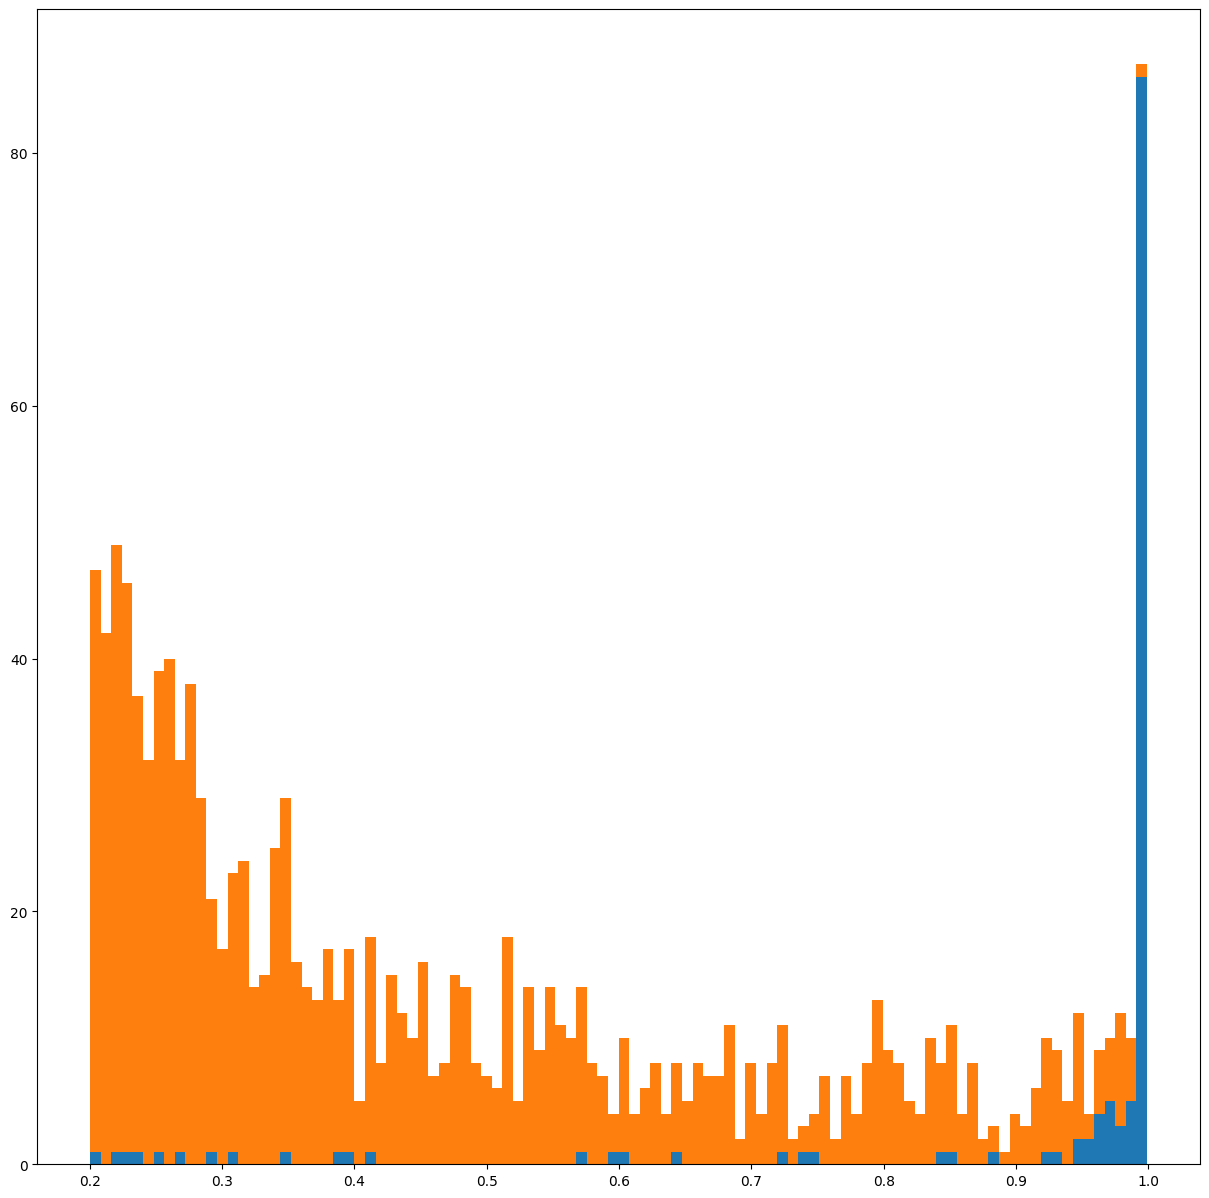

In [21]:
plt.figure(figsize=(15, 15))
_ = plt.hist([pronghorn_scores, false_positive_scores], stacked=True, bins=100)
plt.savefig("/home/koger/Projects/pronghorn-census/outputs/score_histogram.svg", format="svg", bbox_inches="tight")

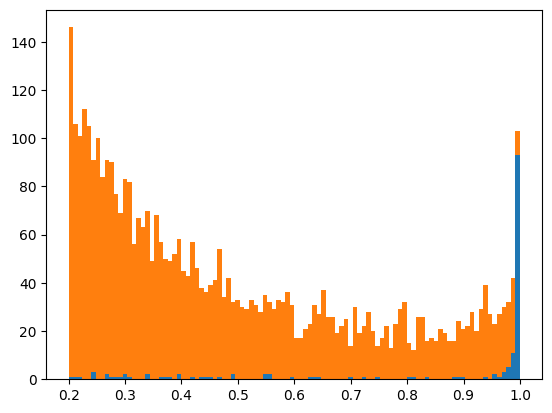

In [ ]:

_ = plt.hist([pronghorn_scores, false_positive_scores], stacked=True, bins=100)

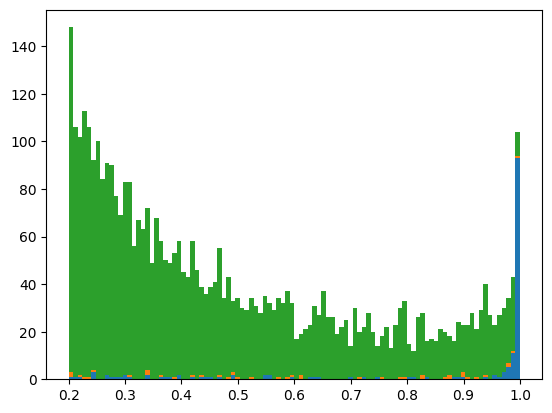

In [38]:
_ = plt.hist([pronghorn_scores, uncertain_scores, false_positive_scores], stacked=True, bins=100)

0.0: 1.00
0.1: 1.00
0.1: 1.00
0.2: 1.00
0.2: 0.99
0.3: 0.96
0.3: 0.91
0.4: 0.89
0.4: 0.86
0.5: 0.84
0.5: 0.83
0.6: 0.80
0.6: 0.79
0.7: 0.78
0.7: 0.76
0.8: 0.76
0.8: 0.74
0.9: 0.73
0.9: 0.71
1.0: 0.00


(0.0, 1.0)

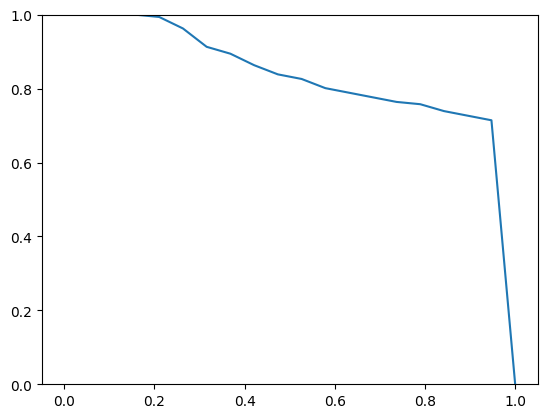

In [29]:
frac_found = []
score_thresh_range = np.linspace(0, 1, 20)
for score_thresh in score_thresh_range:
    frac_found.append(np.sum(pronghorn_scores > score_thresh) / len(pronghorn_scores))
    print(f"{score_thresh:.1f}: {np.sum(pronghorn_scores > score_thresh) / len(pronghorn_scores):.2f}")
plt.plot(score_thresh_range, frac_found)
plt.ylim(0, 1)


In [5]:
# import shutil

In [6]:
# os.path.basename(file)

In [7]:
# files = glob.glob(os.path.join(root, model, f"{herd_unit.lower()}*.npy"))
# len(files)
# os.makedirs(os.path.join("/Users/benkoger/Documents/local_pronghorn", f"{model}-{herd_unit}"), exist_ok=True)
# for ind, file in enumerate(files):
#     if ind % 100 == 0:
#         print(ind)
#     shutil.copy(file, os.path.join("/Users/benkoger/Documents/local_pronghorn", f"{model}-{herd_unit}", os.path.basename(file)))

In [50]:
all_scores = [np.load(f) for f in scores_files[:]]
all_labels = [np.load(f) for f in labels_files[:]]


In [48]:
pronghorn_class = 2
pronghorn_scores = [s[l== pronghorn_class] for s, l in zip(all_scores, all_labels)]
pronghorn_scores = np.concatenate(pronghorn_scores)

NameError: name 'all_scores' is not defined

161


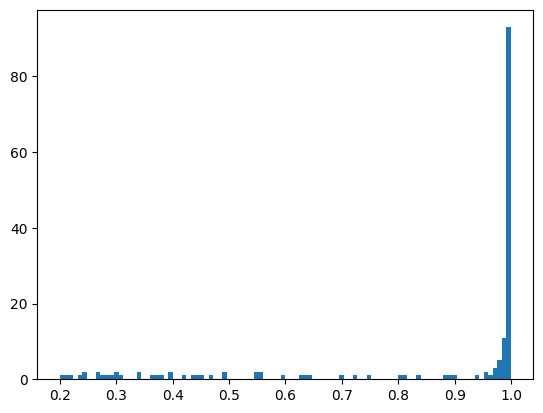

In [39]:
thresh = .1
print(np.sum(pronghorn_scores > thresh))
_ = plt.hist(pronghorn_scores[pronghorn_scores > thresh], bins=100)  

In [49]:
max_scores = []
for scores, labels in zip(all_scores, all_labels):
    if len(scores) == 0:
        max_scores.append(-1)
        continue
    if len(scores[labels==pronghorn_class]) > 0:
        max_scores.append(scores[labels==pronghorn_class].max())
    else:
        max_scores.append(-1)

# scores files sorted by the highest scores within the file
scores_files = [f[1] for f in sorted(zip(max_scores, scores_files), reverse=True)]

NameError: name 'all_scores' is not defined

In [12]:
np.load(scores_files[10])

array([0.9985667 , 0.99770087, 0.70170635, 0.35208988, 0.23915257,
       0.2275252 , 0.20687868, 0.18634343, 0.18439934, 0.17248435,
       0.14971213, 0.1461034 , 0.10308823, 0.10302481, 0.08896592,
       0.06258722, 0.05356465, 0.05353446, 0.05192548], dtype=float32)

quitting


-1

In [17]:
rank_ind = 0
scores_file = scores_files[rank_ind]
image_name = os.path.splitext(os.path.basename(scores_file))[0].split("_scores")[0]
boxes_file = os.path.join(root, model, f"{image_name}_boxes.npy")
image_file = os.path.join(root, herd_unit, f"{image_name}.JPG")
labels_file = os.path.join(root, model, f"{image_name}_labels.npy")

print(os.path.exists(image_file), os.path.exists(boxes_file), os.path.exists(scores_file))

print(scores_file)
print(image_name)

True True True
/Volumes/LaCie/pronghorn/03-24-2025-11-46-27/pr529_by2023_survey1_flight1_00689_20240627_155018_scores.npy
pr529_by2023_survey1_flight1_00689_20240627_155018


In [26]:
np.load(scores_file)

array([0.9991541 , 0.6554022 , 0.5258694 , 0.47464475, 0.24434528,
       0.22617632, 0.16747998, 0.15503375, 0.15358669, 0.12204688,
       0.1047523 , 0.09682316, 0.09660098, 0.0933996 , 0.08603489,
       0.0781347 , 0.07722633, 0.07043649, 0.06249481, 0.06182986,
       0.06165364, 0.06142365, 0.05712466, 0.05010738], dtype=float32)

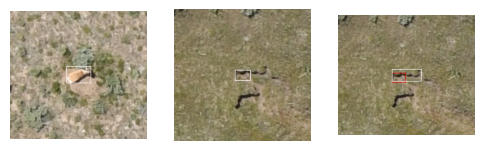

In [37]:
min_score = .2
pronghorn_class = 2

draw_box = True
crop_buffer = 100

image = plt.imread(image_file).copy()
scores = np.load(scores_file)
boxes = np.load(boxes_file)
labels = np.load(labels_file)

num_drawn = 0

crops = []
ph_scores = []

for box, score, label in zip(boxes, scores, labels):
    if (score < min_score) or (label != pronghorn_class):
        continue
    if draw_box:
        cv2.rectangle(image, (box[0], box[1]), (box[2], box[3]), (255, 255, 255), 1)
    ymin = np.max([box[1] - crop_buffer, 0])
    ymax = np.min([box[3] + crop_buffer, image.shape[0]])
    xmin = np.max([box[0] - crop_buffer, 0])
    xmax = np.min([box[2] + crop_buffer, image.shape[1]])
    crops.append(image[ymin:ymax, xmin:xmax].copy())
    ph_scores.append(score)
    if draw_box:
        cv2.rectangle(image, (box[0], box[1]), (box[2], box[3]), (255, 0, 0), 1)
    

crop_size = 2
max_cols = 6
max_crops = 36

crops = crops[:max_crops]
scores = scores[:max_crops]
if len(crops) <= max_cols:
    cols = len(crops)
    rows = 1
else:
    cols = max_cols
    rows = math.ceil(len(crops) / max_cols)
fig, axs = plt.subplots(rows, cols, figsize=(cols * crop_size, rows * crop_size))

# if len(crops) == 1:
#     axs = [axs]
for ax, crop, score in zip(fig.axes[:len(crops)], crops, scores):
    ax.imshow(crop)
    ax.set_axis_off() 


In [27]:
len(labels), len(scores), len(boxes)

(24, 0, 24)

(array([ 10.,  17.,   9.,  12.,   5.,   3.,   8.,   6.,  13.,  13.,   8.,
         10.,  12.,  13.,  10.,   7.,   5.,   8.,   4.,   5.,   4.,   9.,
          8.,   8.,   6.,   6.,   8.,   4.,   6.,   4.,   4.,   5.,   3.,
          4.,   5.,   1.,   4.,   6.,   4.,   3.,   4.,   7.,   4.,   7.,
          7.,   2.,   8.,   5.,   4.,   4.,   7.,   6.,   3.,   5.,   2.,
          2.,   5.,   9.,   3.,   3.,   5.,   3.,   6.,  10.,   8.,   4.,
          3.,   7.,   3.,   9.,   5.,   7.,   6.,   4.,   4.,   5.,   9.,
          6.,   7.,   2.,   2.,   8.,   8.,   5.,   4.,   9.,   8.,   9.,
         11.,   8.,   9.,  12.,  12.,  19.,  16.,  16.,  22.,  29.,  54.,
        125.]),
 array([0.05080686, 0.06029033, 0.06977381, 0.07925728, 0.08874075,
        0.09822422, 0.10770769, 0.11719117, 0.12667464, 0.13615811,
        0.14564158, 0.15512505, 0.16460854, 0.17409201, 0.18357548,
        0.19305895, 0.20254242, 0.2120259 , 0.22150937, 0.23099284,
        0.24047631, 0.24995978, 0.25944325, 0.

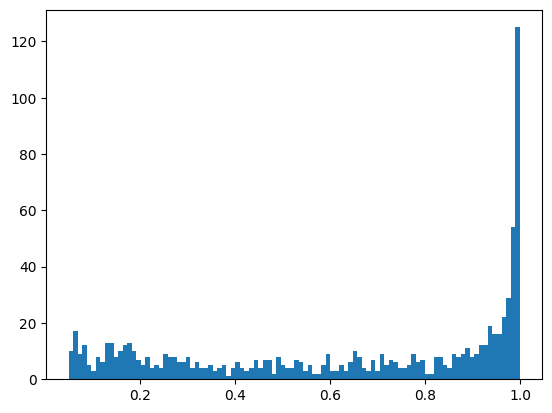

In [11]:
plt.hist([s.max() for s in all_scores if s.size > 0], bins=100)

In [ ]:
crop_size = 200
im_num = 0
scores = all_scores[im_num]


In [ ]:
# glob_string = os.path.join(root, herd_unit, "images", f"{pond_name}_{date:02d}_*.jpg")
# glob_string = os.path.join(root, pond_name, "images", f"{pond_name}_*_*.jpg")
image_files = sorted(glob.glob(glob_string))

In [8]:
cv2.namedWindow('frame')
cv2.setMouseCallback('frame', gui.clicked)

while True:
    gui.draw_keypoints()
    key = cv2.waitKey(500) & 255
    gui.react_to_keypress(key)
    if key == ord('q'):
        gui.save_frame_info()
        print('quitting')
        break
cv2.destroyAllWindows()
cv2.waitKey(1)
cv2.destroyAllWindows()
cv2.waitKey(1)
cv2.destroyAllWindows()
cv2.waitKey(1)

error: OpenCV(4.10.0) /io/opencv/modules/highgui/src/window.cpp:1284: error: (-2:Unspecified error) The function is not implemented. Rebuild the library with Windows, GTK+ 2.x or Cocoa support. If you are on Ubuntu or Debian, install libgtk2.0-dev and pkg-config, then re-run cmake or configure script in function 'cvNamedWindow'


In [7]:
test = "/Volumes/My Passport/salmon-counting-validation/grass/box-info/grass_07_000_1518-3955-0-3696.npy"

In [2]:
import numpy as np

In [9]:
test = "/Users/benkoger/Desktop/salmon-counting-validation/test.npy"

In [10]:
np.save(test, np.ones(10))

In [2]:
x = np.ones((3, 7))

In [7]:
y = np.array([[1,2,3,4,5,6,7]])

In [9]:
np.concatenate((x, y)).shape

(4, 7)

In [2]:
import torch

In [3]:
x = torch.ones((1, 3))
y = torch.ones((8, 3))
z = torch.cat((x, y, y), dim=0)

In [4]:
z.shape

torch.Size([17, 3])